<a href="https://colab.research.google.com/github/nurgissas/ML-personal-learning/blob/main/day02_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 2 — Linear regression — from scratch + sklearn
**Deliverable checklist — your finished notebook must contain:**
1. ✅ Gradient descent loop that recovers w≈3, b≈4 on fake data
2. ✅ Falling loss curve plot
3. ✅ sklearn LinearRegression on California Housing with test MSE + R²
4. ✅ Predicted-vs-actual scatter plot
5. ✅ 2 findings in your words

> Work top to bottom. **EXAMPLE** cells are done for you — copy the pattern. **TODO** cells are yours. Struggle 30+ min before opening the ✅ Solution sketch in the study app.

In [2]:
import numpy as np, matplotlib.pyplot as plt

## Part A — gradient descent from scratch
We make fake data where we KNOW the answer (y = 3x + 4 + noise). If your loop recovers ~3 and ~4, it works.

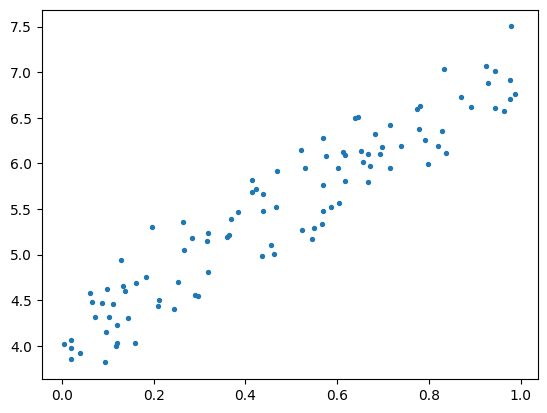

In [3]:
# EXAMPLE — fake data
np.random.seed(0)
x = np.random.rand(100)
y = 3*x + 4 + np.random.randn(100)*0.3
plt.scatter(x, y, s=8); plt.show()

In [5]:
print(len(x))

100


In [60]:
# TODO — fill in the gradient descent loop
# w, b, lr = 0.0, 0.0, 0.005
w, b, lr = 0.0, 0.0, 0.5
# w, b, lr = 0.0, 0.0, 0.1

losses = []
for i in range(1000):
    y_hat = x * w + b                      # TODO: predictions from current w, b
    losses.append(np.mean((y_hat - y)**2))
    dw = 2 * np.mean((y_hat-y) * x)        # TODO
    db = 2 * np.mean(y_hat-y)                 # TODO
    w -= lr*dw
    b -= lr*db
print(w.round(3), b.round(3))   # expect ≈ 3 and ≈ 4

2.981 4.067


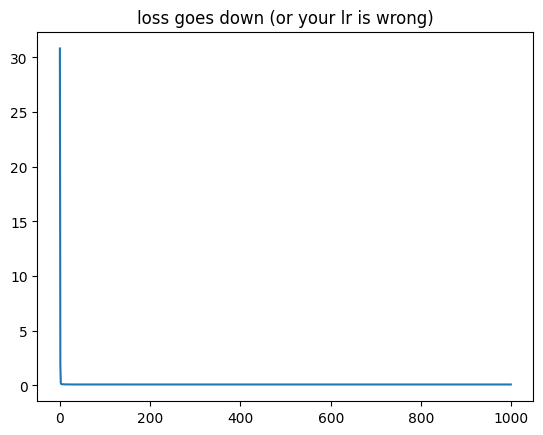

In [61]:
plt.plot(losses); plt.title('loss goes down (or your lr is wrong)'); plt.show()

**TODO — experiment:** rerun with `lr = 0.1` and `lr = 0.001`. Write one sentence about what happened in each case.

### Answer
when lr is small, the convergence to optimal gradient is incremental and steady; on the other hand, when it's big like 5, there is a chance of not convergence as updated weight is going to be changed too big (stack overflow happened)

## Part B — real data with sklearn (downloads itself, no file needed)

In [26]:
# EXAMPLE — load + split
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
d = fetch_california_housing(as_frame=True)
Xtr, Xte, ytr, yte = train_test_split(d.data, d.target, random_state=42)
Xtr.head()

# yte.head()


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
8158,4.2143,37.0,5.288235,0.973529,860.0,2.529412,33.81,-118.12
18368,5.3468,42.0,6.364322,1.087940,957.0,2.404523,37.16,-121.98
19197,3.9191,36.0,6.110063,1.059748,711.0,2.235849,38.45,-122.69
3746,6.3703,32.0,6.000000,0.990196,1159.0,2.272549,34.16,-118.41
13073,2.3684,17.0,4.795858,1.035503,706.0,2.088757,38.57,-121.33


In [29]:
# TODO — fit LinearRegression, print test MSE and R²
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

reg = LinearRegression().fit(Xtr, ytr)

predict = reg.predict(Xte)

mse = mean_squared_error(yte, predict)
print(mse)
r_2 = r2_score(yte, predict)
print(r_2)

0.5411287478470685
0.5910509795491354


MSE 0.5411287478470685 R^2 0.5910509795491354


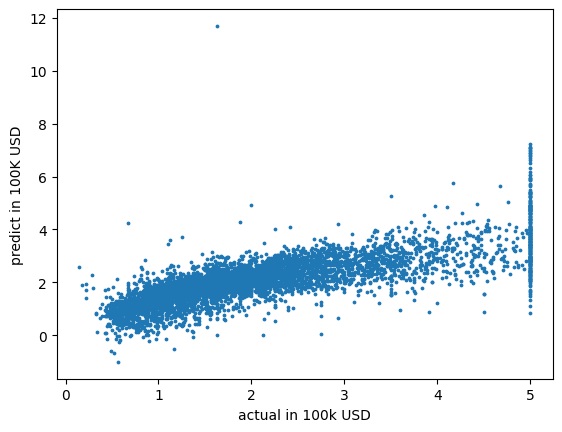

In [63]:
# TODO — scatter plot: x-axis actual (yte), y-axis predicted
print('MSE',mse, 'R^2', r_2)

plt.scatter(yte, predict, s=3)
plt.xlabel('actual in 100k USD')
plt.ylabel('predict in 100K USD')
plt.show()

Findings 2: sentences: how good is R²? Where does the model struggle (look at the scatter)?

house values more than 500k were cliped when the data was collected -> that's why there are many points at 5, which in reality could be worth 6-10, etc (Censored target). All the dataset with target more than 500001 could be discarded to have higher R^2 value.